# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [1]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Deborah Villicaña Prieto"            # Tu nombre completo
MATRICULA = "80374"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "migracion"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Deborah Villicaña Prieto
Matrícula: 80374
Dataset asignado: migracion


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [2]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\debor\anaconda3\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: migracion
Descripcion: Numero total de inmigrantes internacionales residiendo en el pais (personas)


In [4]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [5]:
df.head(25)

,entity,code,year,valor,owid_region
0,Afghanistan,AFG,1990,57686,Asia
1,Afghanistan,AFG,1995,71522,Asia
2,Afghanistan,AFG,2000,75917,Asia
3,Afghanistan,AFG,2005,87314,Asia
4,Afghanistan,AFG,2010,102276,Asia
5,Afghanistan,AFG,2015,339432,Asia
6,Afghanistan,AFG,2020,144098,Asia
7,Afghanistan,AFG,2024,98110,Asia
8,Africa,OWID_AFR,1990,16176915,NaN
9,Africa,OWID_AFR,1995,16653698,NaN


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [6]:
# Forma del dataset (filas, columnas)
df.shape


(2144, 5)

In [7]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2144 entries, 0 to 2143
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   entity       2144 non-null   object
 1   code         1960 non-null   object
 2   year         2144 non-null   int64 
 3   valor        2144 non-null   int64 
 4   owid_region  1824 non-null   object
dtypes: int64(2), object(3)
memory usage: 83.9+ KB


In [8]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count    2.144000e+03
mean     4.987920e+06
std      1.998549e+07
min      1.080000e+02
25%      3.905450e+04
50%      2.187635e+05
75%      1.420072e+06
max      3.040218e+08
Name: valor, dtype: float64

In [9]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity           0
code           184
year             0
valor            0
owid_region    320
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

Puedo inferir que los valores nulos son mayormente ddebido a una falta de asignación manual de un código, ya que de año y valor no falta ninguno. Sobre la región sí hay más datos nulos, yo puedo pensar que se debe a que se desconoce de dónder provienen estos inmigrantes. 
Sobre el rango de años, se puede considerar que es "reciente" ya que no sobrepasa los 50 años de antigüedad de estos datos, pero sí es un rango suficiente ya que han pasado muchas cosas en estos años. 
Sobre el tipo de variable, solo es numérico el año y el valor, el resto estamos manejando objetos

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [10]:
# Pregunta 1
# Tu codigo aqui

df_paises = df[df["owid_region"].notna()].copy()
n_paises = df_paises["entity"].nunique()
print(f"Número de países distintos: {n_paises}")


Número de países distintos: 228


In [11]:
df_paises.sort_values("valor", ascending=False).head(10)

,entity,code,year,valor,owid_region
2015,United States,USA,2024,52375047,North America
2014,United States,USA,2020,50471028,North America
2013,United States,USA,2015,47942986,North America
2012,United States,USA,2010,43947211,North America
2011,United States,USA,2005,39545828,North America
2010,United States,USA,2000,34806848,North America
2009,United States,USA,1995,28525723,North America
2008,United States,USA,1990,23266147,North America
719,Germany,DEU,2024,16750084,Europe
718,Germany,DEU,2020,15021300,Europe


In [12]:
df_paises.sort_values("valor", ascending=True).head(10)

,entity,code,year,valor,owid_region
1586,Saint Helena,SHN,2000,108,Africa
1585,Saint Helena,SHN,1995,117,Africa
1587,Saint Helena,SHN,2005,163,Africa
1584,Saint Helena,SHN,1990,178,Africa
1971,Tuvalu,TUV,2005,209,Oceania
1970,Tuvalu,TUV,2000,218,Oceania
1972,Tuvalu,TUV,2010,220,Oceania
1973,Tuvalu,TUV,2015,230,Oceania
1974,Tuvalu,TUV,2020,239,Oceania
1975,Tuvalu,TUV,2024,246,Oceania


**Interpretación:**

Estados Unidos es el país que más inmigrantes tiene, y por mucho, ya que su año más antiguo, que es 1990, sigue superando la cantidad de inmigrantes que tiene Alemania en el último año registrado por más de 7 millones de inmigrantes. Es decir, comparándolos con el mismo año, Estados Unidos tiene un 212% más de inmigrantes que Alemania.

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [13]:
# Pregunta 2
# Tu codigo aqui

#print(df_paises.head(50))
italy = df[df["entity"] == "Italy"]
year_italy =  italy['year'].to_numpy() 

ireland = df[df["entity"] == "Ireland"]
year_ireland = ireland['year'].to_numpy()

print(year_ireland)

common_years = np.intersect1d(
    year_ireland,
    year_italy
)

len(common_years)
type(common_years)

[1990 1995 2000 2005 2010 2015 2020 2024]


numpy.ndarray

In [14]:
italy = df[df['entity'] == 'Italy']
ireland = df[df['entity'] == 'Ireland']

italy.shape
ireland.shape
ireland.head()

,entity,code,year,valor,owid_region
888,Ireland,IRL,1990,227783,Europe
889,Ireland,IRL,1995,247379,Europe
890,Ireland,IRL,2000,376321,Europe
891,Ireland,IRL,2005,620579,Europe
892,Ireland,IRL,2010,751381,Europe


In [15]:
comparison_it_ire = pd.merge(
    italy[["year", "valor"]],
    ireland[["year", "valor"]],
    on = "year",
    suffixes = ("_italy", "_ireland")
)

comparison_it_ire.head

<bound method NDFrame.head of    year  valor_italy  valor_ireland
0  1990      1529367         227783
1  1995      1810642         247379
2  2000      2143259         376321
3  2005      3285903         620579
4  2010      4719233         751381
5  2015      5506199         802470
6  2020      6223851         951686
7  2024      6553671        1216237>

### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [16]:
# Pregunta 3
# Tu codigo aqui
# Pregunta 3
paises = ['Canada', 'Spain', 'United States', 'Mexico', 'United Kingdom']

comparacion = (
    df_paises[df_paises['entity'].isin(paises)]
    .sort_values('year')
    .groupby('entity')
    .tail(1)[['entity', 'year', 'valor']]
    .reset_index(drop=True)
    .sort_values('valor', ascending=False)
)

print(comparacion)

pais_max = comparacion.iloc[0]
pais_min = comparacion.iloc[-1]
diferencia = pais_max['valor'] - pais_min['valor']

print(f"Mayor: {pais_max['entity']} ({pais_max['valor']}, año {pais_max['year']})")
print(f"Menor: {pais_min['entity']} ({pais_min['valor']}, año {pais_min['year']})")
print(f"Diferencia: {diferencia}")

           entity  year     valor
4   United States  2024  52375047
1  United Kingdom  2024  11845479
2           Spain  2024   8870527
3          Canada  2024   8805839
0          Mexico  2024   1726089
Mayor: United States (52375047, año 2024)
Menor: Mexico (1726089, año 2024)
Diferencia: 50648958


**Interpretación:**

Estados Unidos sigue siendo el país con más inmigrantes. POr otro lado, a pesar de que México está al lado de Estados Unidos, y muchos de los inmigrantes de América pasan por México para llegar a Estados Unidos, son pocos los que se quedan en México. Esto me lleva a pensar que mcuhos de sus inmigrantes no solo vienen del continente americano. 
Ahora, sobre El Reino Unido, este sería el país europeo con más inmigración, seguido por España.

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [17]:
# Pregunta 4
# Tu codigo aqui
latinoamerica = ["Mexico", "Colombia", "Argentina"]
asia = ["China", "Japan", "Vietnam"]
df_paises[df_paises['entity'].isin(latinoamerica)]


,entity,code,year,valor,owid_region
72,Argentina,ARG,1990,1647935,South America
73,Argentina,ARG,1995,1589660,South America
74,Argentina,ARG,2000,1543851,South America
75,Argentina,ARG,2005,1641560,South America
76,Argentina,ARG,2010,1799680,South America
77,Argentina,ARG,2015,1856613,South America
78,Argentina,ARG,2020,1912294,South America
79,Argentina,ARG,2024,1958039,South America
384,Colombia,COL,1990,100672,South America
385,Colombia,COL,1995,109550,South America


In [18]:
df_paises[df_paises['entity'].isin(asia)]

,entity,code,year,valor,owid_region
376,China,CHN,1990,518395,Asia
377,China,CHN,1995,610608,Asia
378,China,CHN,2000,720915,Asia
379,China,CHN,2005,853360,Asia
380,China,CHN,2010,1010008,Asia
381,China,CHN,2015,1196007,Asia
382,China,CHN,2020,1415116,Asia
383,China,CHN,2024,1638718,Asia
928,Japan,JPN,1990,1050475,Asia
929,Japan,JPN,1995,1331094,Asia


In [19]:
def dato_reciente(paises):
    return (
        df_paises[df_paises['entity'].isin(paises)]
        .sort_values('year')
        .groupby('entity')
        .tail(1)[['entity', 'year', 'valor']]
    )

datos_latam = dato_reciente(latinoamerica)
datos_asia = dato_reciente(asia)

promedio_latam = datos_latam['valor'].mean()
promedio_asia = datos_asia['valor'].mean()

print(datos_latam)
print(f"Promedio Latinoamérica: {promedio_latam}\n")

print(datos_asia)
print(f"Promedio Asia: {promedio_asia}")

         entity  year    valor
79    Argentina  2024  1958039
391    Colombia  2024  3063518
1199     Mexico  2024  1726089
Promedio Latinoamérica: 2249215.3333333335

       entity  year    valor
383     China  2024  1638718
935     Japan  2024  3409529
2079  Vietnam  2024   326418
Promedio Asia: 1791555.0


**Interpretación:**

Latinoamérica tiene muchas más migraciones que Asia, conformado por China, Japón y Vietnam. A pesar de que Japón sí recibe muchos inmigrantes, China y Vietnam reciben muy pocos, lo que impacta en el promedio del continente

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [20]:
# Pregunta 5
# Tu codigo aqui
ukraine = df[df['entity'] == 'Ukraine'].sort_values('year')
max_year = ukraine.loc[ukraine['valor'].idxmax(), 'year']
valor_max = ukraine['valor'].max()

min_year = ukraine.loc[ukraine['valor'].idxmin(), 'year']
valor_min = ukraine['valor'].min()
print(ukraine[['year', 'valor']])

print(f"Máximo: {valor_max} en {max_year}")
print(f"Mínimo: {valor_min} en {min_year}")

      year    valor
1984  1990  6892920
1985  1995  6172338
1986  2000  5527087
1987  2005  5050302
1988  2010  4818767
1989  2015  4915142
1990  2020  4997387
1991  2024  5064173
Máximo: 6892920 en 1990
Mínimo: 4818767 en 2010


In [21]:
ukraine.head()

,entity,code,year,valor,owid_region
1984,Ukraine,UKR,1990,6892920,Europe
1985,Ukraine,UKR,1995,6172338,Europe
1986,Ukraine,UKR,2000,5527087,Europe
1987,Ukraine,UKR,2005,5050302,Europe
1988,Ukraine,UKR,2010,4818767,Europe


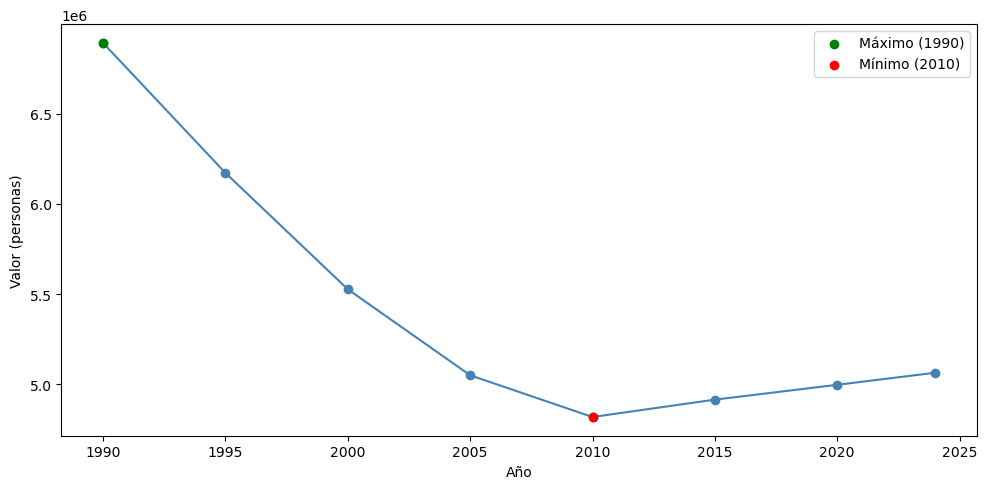

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(ukraine['year'], ukraine['valor'], marker='o', color='steelblue')

# Resaltar el máximo y el mínimo
plt.scatter(max_year, valor_max, color='green', zorder=5, label=f'Máximo ({max_year})')
plt.scatter(min_year, valor_min, color='red', zorder=5, label=f'Mínimo ({min_year})')

plt.xlabel('Año')
plt.ylabel(f"Valor ({config['unidad']})")
plt.legend()
plt.tight_layout()
plt.show()


**Interpretación:**

Por muchos años, Ukrania tenía una tendencia de migración decreciente, pero a partir del 2010 se presenta un punto de inflexión donde comienza a ascender

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [23]:
# Pregunta 6
# Tu codigo aqui

datos_mexico = df_paises[df_paises['entity'] == 'Mexico'].sort_values('year')

anio_inicial, valor_inicial = datos_mexico[['year', 'valor']].iloc[0]
anio_final, valor_final = datos_mexico[['year', 'valor']].iloc[-1]
cambio_pct = (valor_final - valor_inicial) / valor_inicial * 100

print(f"{anio_inicial}: {valor_inicial}")
print(f"{anio_final}: {valor_final}")
print(f"Cambio porcentual: {cambio_pct:.2f}%")

1990: 701513
2024: 1726089
Cambio porcentual: 146.05%


**Interpretación:**

Es un incremento relativo, y yo considero que se debe a que más personas están buscando más oportunidades en otros países.

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [24]:
# Pregunta 7
# Tu codigo aqui
anio_reciente = df_paises['year'].max()
valores = df_paises.loc[df_paises['year'] == anio_reciente, 'valor'].dropna().to_numpy()

media = np.mean(valores)
mediana = np.median(valores)
desviacion = np.std(valores)

print(f"Año analizado: {anio_reciente}")
print(f"Media: {media}")
print(f"Mediana: {mediana}")
print(f"Desviación estándar: {desviacion}")

Año analizado: 2024
Media: 1332886.144736842
Mediana: 202554.0
Desviación estándar: 4083060.7011782746


**Interpretación:**

Se tiene una desviación estándar muy alta entre los países. Así de generalizado, creo que es difícil encontrar un patrón sobre la diferencia en la cantidad de desviación, pero considero que sería interesante ver el comportamiento por diferentes categorías, por ejemplo, inseguridad, zona, status, etc

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

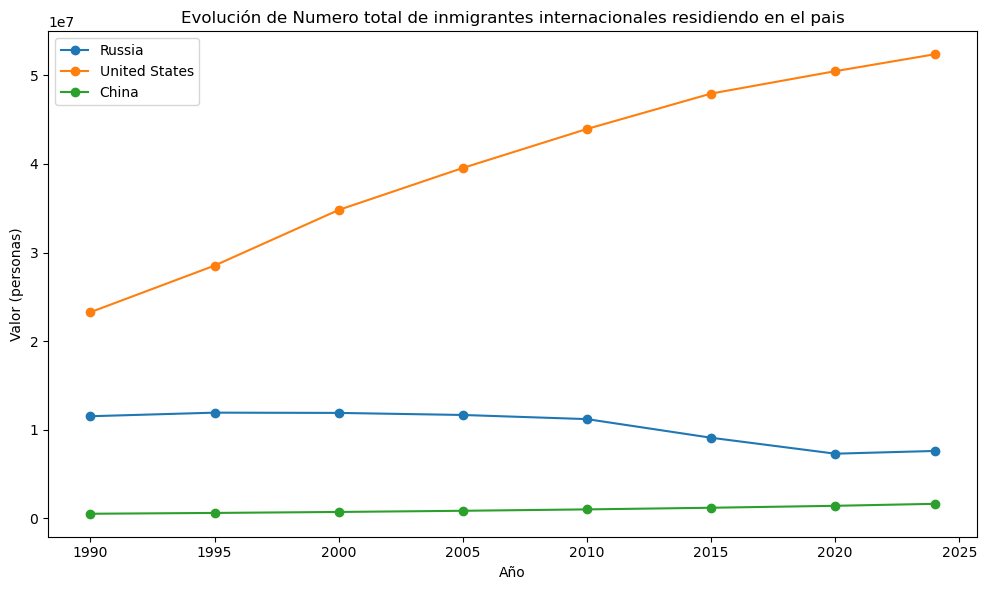

In [25]:
# Pregunta 8
# Tu codigo aqui

paises_grafica = ['Russia', 'United States', 'China']

plt.figure(figsize=(10, 6))
for pais in paises_grafica:
    datos = df_paises[df_paises['entity'] == pais].sort_values('year')
    plt.plot(datos['year'], datos['valor'], marker='o', label=pais)

plt.xlabel('Año')
plt.ylabel(f"Valor ({config['unidad']})")
plt.title(f"Evolución de {config['descripcion']}")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretación:**

Claramente, Estados Unidos sigue ganando por mucho en la cantidad de inmigrantes residiendo en el país. Rusia, a pesar de ser un país exótico y ambientalmente frío, recibe más inmigrantes que China

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

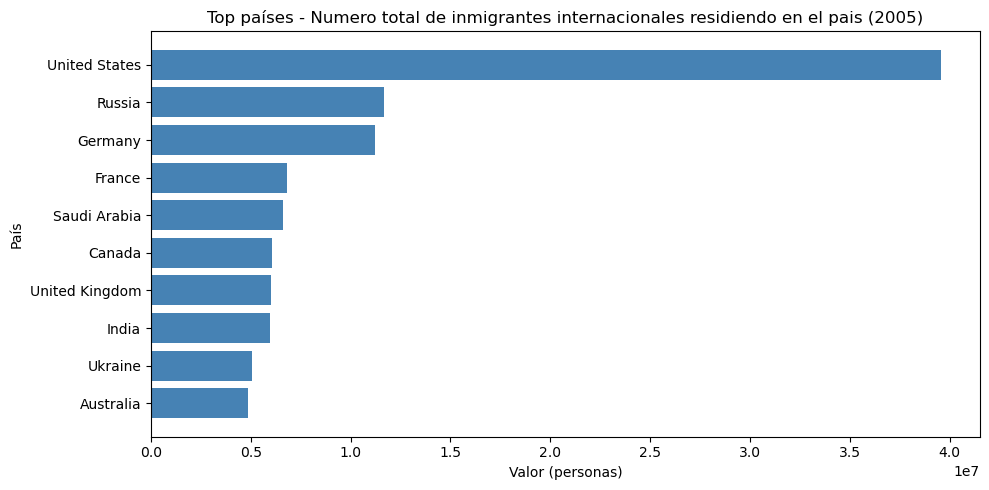

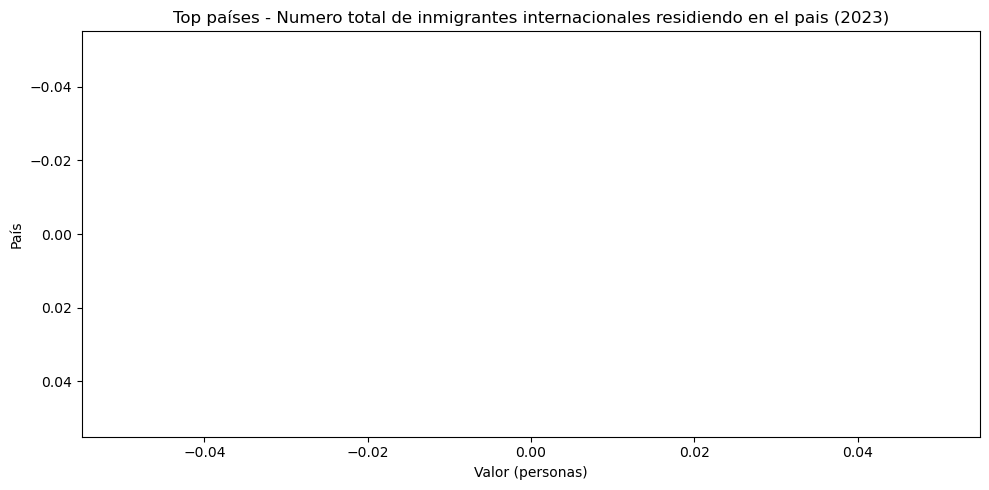

Año nacimiento: 2005 ['United States', 'Russia', 'Germany', 'France', 'Saudi Arabia', 'Canada', 'United Kingdom', 'India', 'Ukraine', 'Australia']
Top 2023: []


In [26]:
# Pregunta 9
df_paises = df[df[config["filtro_paises"]].notnull()]

anio_consultado = 2005  # tu año de nacimiento

top = (
    df_paises[df_paises['year'] == anio_consultado]
    .sort_values('valor', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top['entity'], top['valor'], color='steelblue')
plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_consultado})")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

anio_2023 = 2023

top_2023 = (
    df_paises[df_paises['year'] == anio_2023]
    .sort_values('valor', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top_2023['entity'], top_2023['valor'], color='indianred')
plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_2023})")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Para comparar qué países entraron/salieron del top 10:
print("Año nacimiento: 2005", top['entity'].tolist())
print("Top 2023:", top_2023['entity'].tolist())


**Interpretación:**

En la primer gráfica, se puede ver cómo Estados Unidos seguia siendo líder en esta categoría, pero a diferencia del año más reciente de los datos "2024", aquí Rusia es quien le sigue en la cantidad de migraciones. En la segunda gráfica no se puede visualizar nada ya que no existen datos registrados para ese año. 

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

Con este dataset pude aprender sobre el comportamiento de las personas a través de los años, sobre cómo deciden hacer cambios en su vivienda como consecuencia de contextos de sus países y al final se ve reflejado en la estadística. Por ejemplo, en el caso de Ukrania me dio curiosidad ver cómo se había comportado últimamente debido a los conflictos que ha habido con Rusia, y efectivamente, a partir del 2010 comenzó a incrementar su número de migraciones. Por otro lado, algunos datos limitantes fueron que para algunos datos de owid_region, había datos nulos o códigos que no tenían que ver, lo cual dificultaba más el filtrado de los datos. Creo que además sería interesante extraer conclusiones pero considerando edades, ya que a partir de esto se puede entender un poco más el comportamiento, por ejemplo en el caso de jóvenes, se puede deber por razones de estudio.
Esto es lo que haría si tuviera más tiempo, además de investigar un poco más sobre el contexto de cada región

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
